AQI DASHBOARD SUMMARY
Average AQI: 252.78
Maximum AQI: 499.9
Minimum AQI: 0.4
Most Polluted Year: 2023
Least Polluted Year: 2020


C:\Users\hi\AppData\Local\Temp\ipykernel_17752\3895696632.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


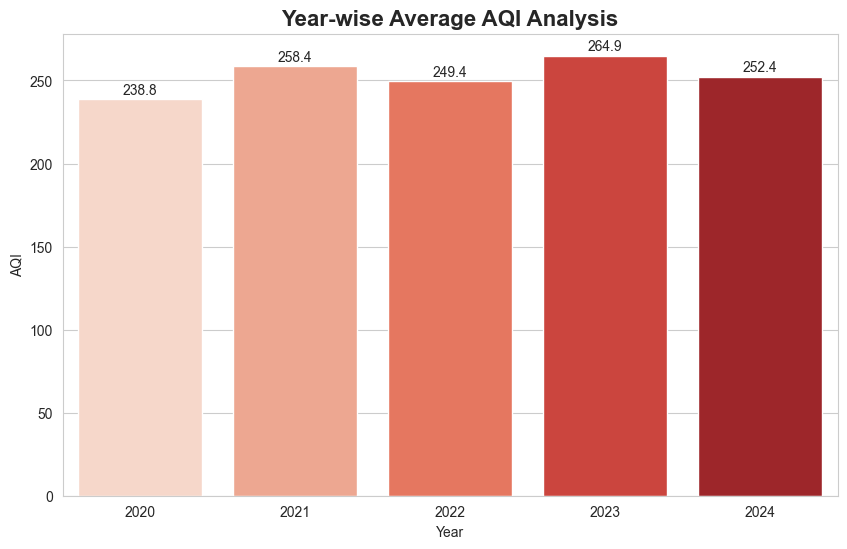

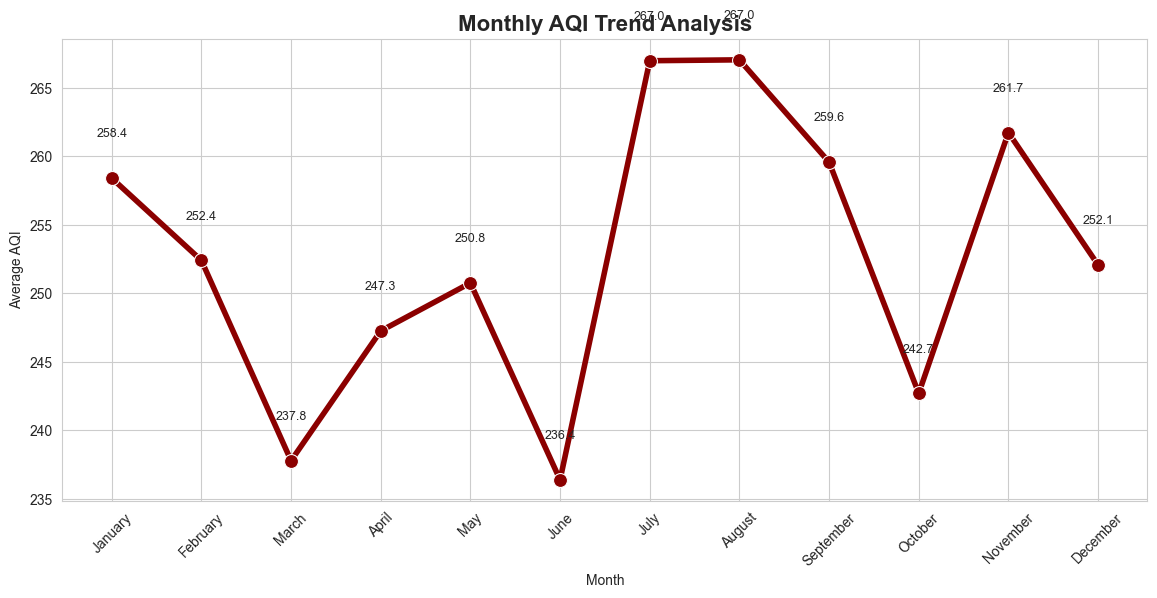


MONTHLY INSIGHTS:
Monthly AQI variation indicates fluctuating pollution levels across the year.
Higher AQI periods may be influenced by seasonal weather conditions and emission patterns.


C:\Users\hi\AppData\Local\Temp\ipykernel_17752\3895696632.py:170: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


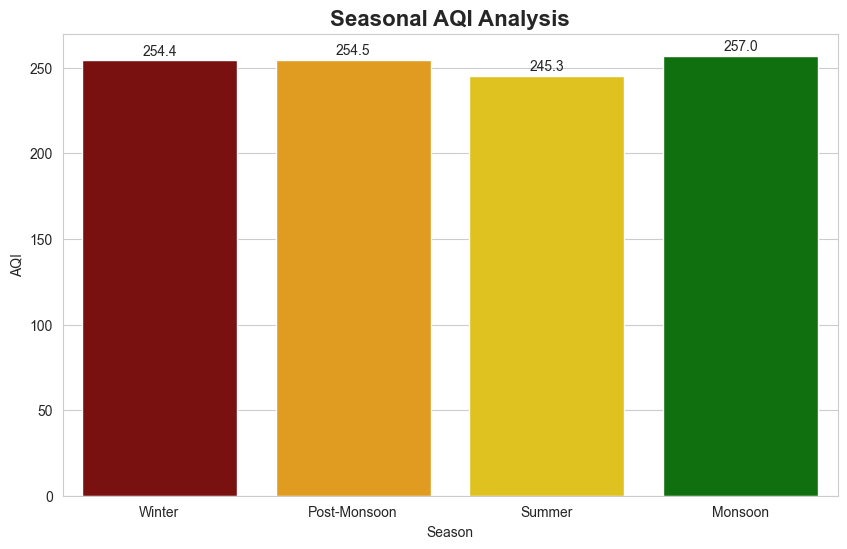

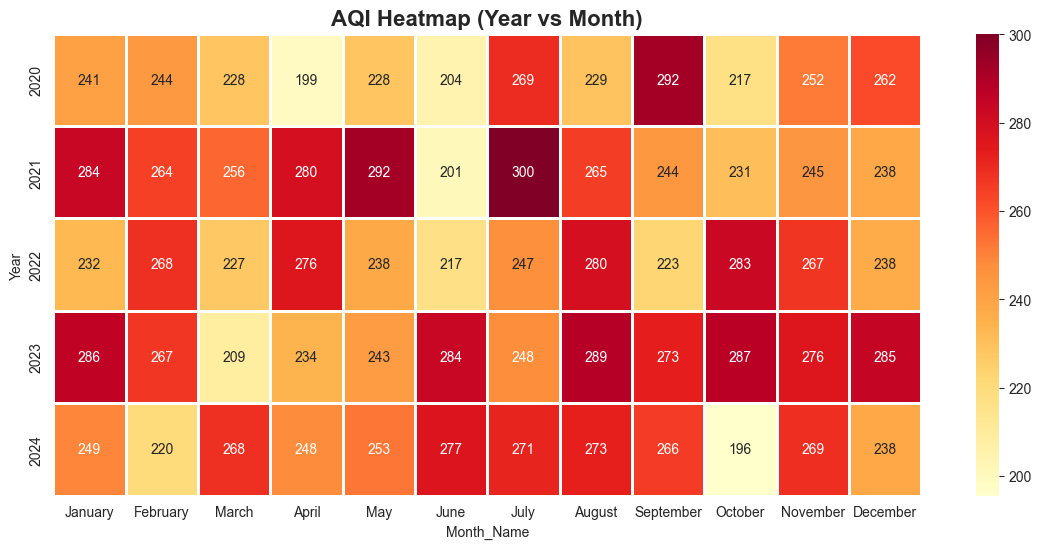


INSIGHTS:
Winter shows severe AQI due to inversion and pollutant trapping.
Post-monsoon remains highly polluted because of stubble burning and festival emissions.
Monsoon generally records lower AQI due to rainfall washout.
2020 shows relatively cleaner air because of lockdown effects.


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12,6)

# LOAD
df = pd.read_csv("../data/cleaned_aqi_final.csv")
df['Date'] = pd.to_datetime(df['Date'])

df = df[(df['AQI'] >= 0) & (df['AQI'] <= 500)]

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.month_name()

# BETTER SEASON MAPPING
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Summer"
    elif month in [6, 7, 8]:
        return "Monsoon"
    else:
        return "Post-Monsoon"

df['Season'] = df['Month'].apply(get_season)

month_order = [
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
]

# ======================
# DASHBOARD SUMMARY
# ======================
print("="*60)
print("AQI DASHBOARD SUMMARY")
print("="*60)

print("Average AQI:", round(df['AQI'].mean(),2))
print("Maximum AQI:", df['AQI'].max())
print("Minimum AQI:", df['AQI'].min())

most_polluted_year = df.groupby('Year')['AQI'].mean().idxmax()
least_polluted_year = df.groupby('Year')['AQI'].mean().idxmin()

print("Most Polluted Year:", most_polluted_year)
print("Least Polluted Year:", least_polluted_year)

# ======================
# YEARLY
# ======================
yearly = df.groupby('Year')['AQI'].mean().reset_index()

plt.figure(figsize=(10,6))
sns.barplot(
    data=yearly,
    x='Year',
    y='AQI',
    palette='Reds'
)

plt.title("Year-wise Average AQI Analysis", fontsize=16, fontweight='bold')

for i, val in enumerate(yearly['AQI']):
    plt.text(i, val+3, round(val,1), ha='center')

plt.show()

# ======================
# MONTHLY
# ======================
# ======================
# MONTHLY AQI CATEGORY ANALYSIS
# ======================

# ======================
# MONTHLY AQI TREND (SMOOTHED)
# ======================

# ======================
# MONTHLY AQI ANALYSIS
# ======================

# =========================
# MONTHLY AQI ANALYSIS
# =========================

month_order = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]

monthly = df.groupby('Month_Name')['AQI'].mean().reset_index()

monthly['Month_Name'] = pd.Categorical(
    monthly['Month_Name'],
    categories=month_order,
    ordered=True
)

monthly = monthly.sort_values('Month_Name')

plt.figure(figsize=(14,6))

sns.lineplot(
    data=monthly,
    x='Month_Name',
    y='AQI',
    marker='o',
    linewidth=4,
    markersize=10,
    color='darkred'
)

plt.xticks(rotation=45)

plt.title(
    "Monthly AQI Trend Analysis",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Month")
plt.ylabel("Average AQI")

for i, val in enumerate(monthly['AQI']):
    plt.text(
        i,
        val + 3,
        round(val, 1),
        ha='center',
        fontsize=9
    )

plt.show()

print("\nMONTHLY INSIGHTS:")
print("Monthly AQI variation indicates fluctuating pollution levels across the year.")
print("Higher AQI periods may be influenced by seasonal weather conditions and emission patterns.")

# ======================
# SEASONAL
# ======================
season_order = [
    'Winter',
    'Post-Monsoon',
    'Summer',
    'Monsoon'
]

seasonal = df.groupby('Season')['AQI'].mean().reset_index()

seasonal['Season'] = pd.Categorical(
    seasonal['Season'],
    categories=season_order,
    ordered=True
)

seasonal = seasonal.sort_values('Season')

plt.figure(figsize=(10,6))

colors = ['darkred','orange','gold','green']

sns.barplot(
    data=seasonal,
    x='Season',
    y='AQI',
    palette=colors
)

for i, val in enumerate(seasonal['AQI']):
    plt.text(i, val+3, round(val,1), ha='center')

plt.title(
    "Seasonal AQI Analysis",
    fontsize=16,
    fontweight='bold'
)

plt.show()

# ======================
# HEATMAP
# ======================
pivot = df.pivot_table(
    values='AQI',
    index='Year',
    columns='Month_Name',
    aggfunc='mean'
)

pivot = pivot[month_order]

plt.figure(figsize=(14,6))

sns.heatmap(
    pivot,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd",
    linewidths=1
)

plt.title(
    "AQI Heatmap (Year vs Month)",
    fontsize=16,
    fontweight='bold'
)

plt.show()

# ======================
# INTERPRETATION
# ======================
print("\nINSIGHTS:")
print("Winter shows severe AQI due to inversion and pollutant trapping.")
print("Post-monsoon remains highly polluted because of stubble burning and festival emissions.")
print("Monsoon generally records lower AQI due to rainfall washout.")
print("2020 shows relatively cleaner air because of lockdown effects.")